Crop recomendation


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [54]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [56]:
df['label'].value_counts()


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [57]:
df1 = df[df['label']== 'rice'] 
df2 = df[df['label']== 'cotton'] 
df1

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
95,88,46,42,22.683191,83.463583,6.604993,194.265172,rice
96,93,47,37,21.533463,82.140041,6.500343,295.924880,rice
97,60,55,45,21.408658,83.329319,5.935745,287.576694,rice
98,78,35,44,26.543481,84.673536,7.072656,183.622266,rice


In [58]:
df1['K'].value_counts()

K
38    17
42    11
36    10
43     9
41     9
40     9
44     8
39     8
37     7
35     6
45     6
Name: count, dtype: int64

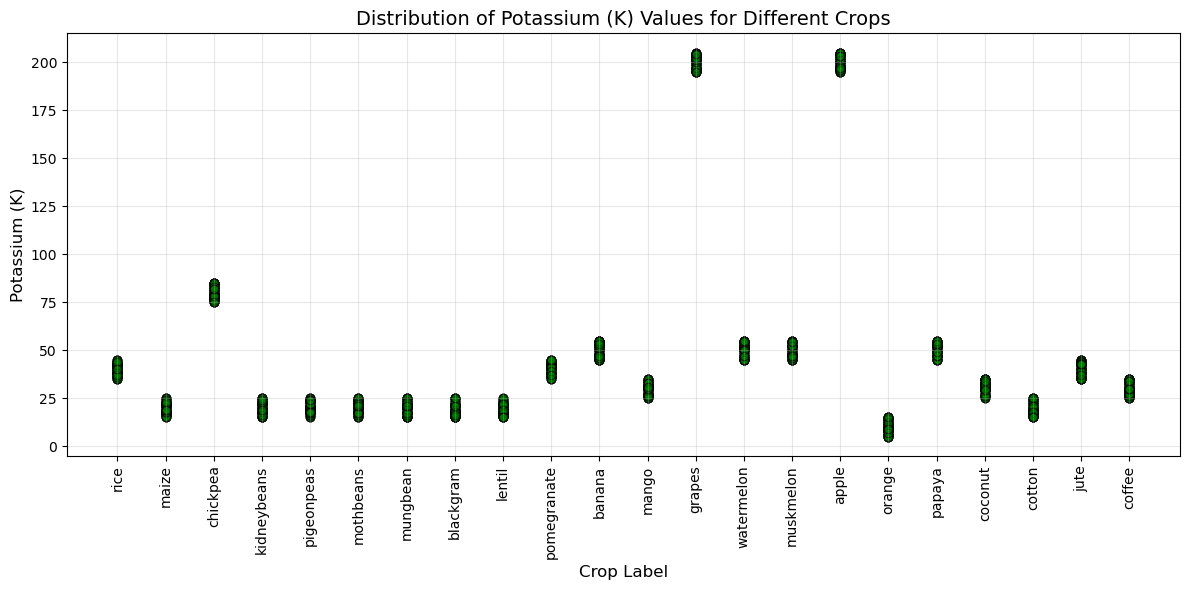

In [59]:
# Distribution of K values across all crops
plt.figure(figsize=(12, 6))
plt.scatter(df['label'], df['K'], alpha=0.6, c='green', edgecolors='black')
plt.xlabel('Crop Label', fontsize=12)
plt.ylabel('Potassium (K)', fontsize=12)
plt.title('Distribution of Potassium (K) Values for Different Crops', fontsize=14)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

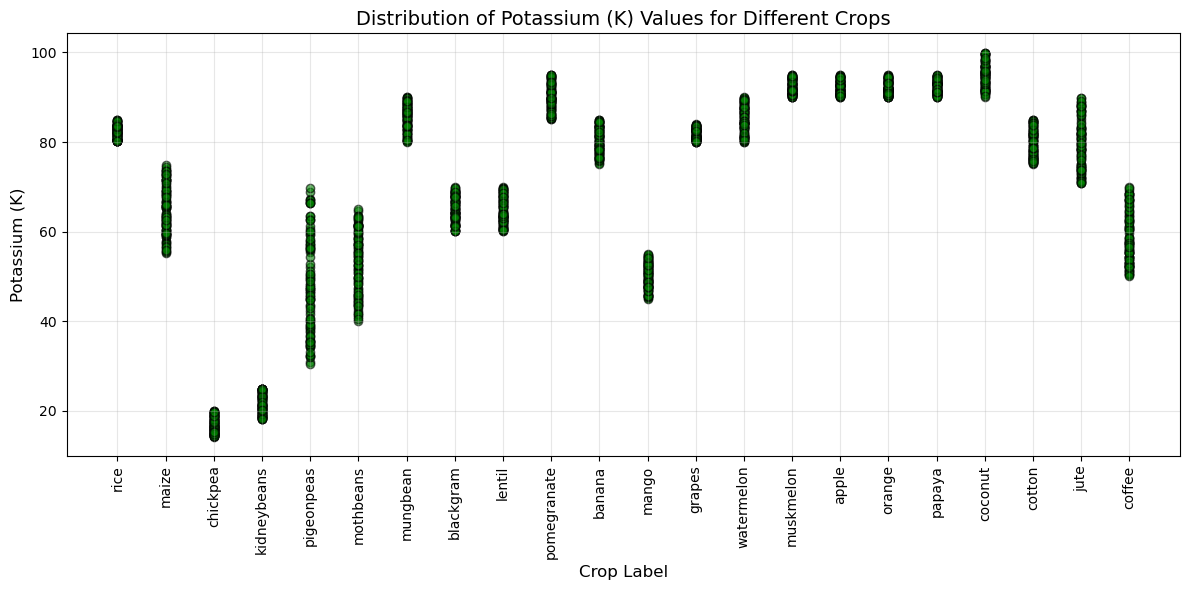

In [60]:
# Distribution of K values across all crops
plt.figure(figsize=(12, 6))
plt.scatter(df['label'], df["humidity"], alpha=0.6, c='green', edgecolors='black')
plt.xlabel('Crop Label', fontsize=12)
plt.ylabel('Potassium (K)', fontsize=12)
plt.title('Distribution of Potassium (K) Values for Different Crops', fontsize=14)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
x= df.drop('label' , axis=1)
y= df['label']

In [62]:
# train test split
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , train_size= 0.75 , random_state= 42 , shuffle=True)

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay,\
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [64]:
from sklearn.preprocessing import LabelEncoder

# Encode labels for all models (required for XGBoost)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost" : AdaBoostClassifier(),
    "XGBoost" : XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train_encoded) # Train model with encoded labels

    # Make predictions (will be numeric)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Get probability predictions for ROC AUC
    y_train_pred_proba = model.predict_proba(x_train)
    y_test_pred_proba = model.predict_proba(x_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train_encoded, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train_encoded, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train_encoded, y_train_pred, average='weighted') # Calculate Precision
    model_train_recall = recall_score(y_train_encoded, y_train_pred, average='weighted') # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train_encoded, y_train_pred_proba, multi_class='ovr')


    # Test set performance
    model_test_accuracy = accuracy_score(y_test_encoded, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test_encoded, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test_encoded, y_test_pred, average='weighted') # Calculate Precision
    model_test_recall = recall_score(y_test_encoded, y_test_pred, average='weighted') # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test_encoded, y_test_pred_proba, multi_class='ovr') #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

c:\Users\YASH JAIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logisitic Regression
Model performance for Training set
- Accuracy: 0.9739
- F1 score: 0.9739
- Precision: 0.9742
- Recall: 0.9739
- Roc Auc Score: 0.9997
----------------------------------
Model performance for Test set
- Accuracy: 0.9418
- F1 score: 0.9412
- Precision: 0.9436
- Recall: 0.9418
- Roc Auc Score: 0.9989


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9873
- F1 score: 0.9872
- Precision: 0.9879
- Recall: 0.9873
- Roc Auc Score: 0.9935


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9909
- F1 score: 0.9908
- Precision: 0.9923
- Recall: 0.9909
- Roc Auc Score: 0.9999


Gradient Boost
Model performance for Training se

c:\Users\YASH JAIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\YASH JAIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


XGBoost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9818
- F1 score: 0.9817
- Precision: 0.9833
- Recall: 0.9818
- Roc Auc Score: 0.9993




In [65]:
xgboost_param = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [66]:
# Models list for Hyperparameter tuning
# tuple hold name_model , model , parameter
randomcv_models = [
                
                   ("XGBoost", XGBClassifier(), xgboost_param)
                   
                   ]

In [67]:
from sklearn.model_selection import RandomizedSearchCV
model_param = {}
for name , model  , params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions= params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)
    random.fit(x_train , y_train_encoded)
    model_param[name] = random.best_params_

for model_name in model_param:
    print('------------Best parameter-----------')
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits


KeyboardInterrupt: 

In [68]:
# Train XGBoost model with best parameters
best_xgb_model = XGBClassifier(
    subsample=0.8,
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.3,
    colsample_bytree=0.9
)

# Train the model
best_xgb_model.fit(x_train, y_train_encoded)

# Make predictions
y_pred = best_xgb_model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"XGBoost Model Accuracy: {accuracy:.4f}")
print(f"XGBoost Model Accuracy: {accuracy*100:.2f}%")

XGBoost Model Accuracy: 0.9855
XGBoost Model Accuracy: 98.55%


In [69]:
# Save the model and label encoder as pickle files
import pickle

# Save the trained model
with open('xgboost_crop_model.pkl', 'wb') as file:
    pickle.dump(best_xgb_model, file)

# Save the label encoder
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)

print("✓ Model saved as 'xgboost_crop_model.pkl'")
print("✓ Label encoder saved as 'label_encoder.pkl'")

✓ Model saved as 'xgboost_crop_model.pkl'
✓ Label encoder saved as 'label_encoder.pkl'
